In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("amazon_ecommerce_1M.csv")

Text(0.5, 1.0, 'Categories')

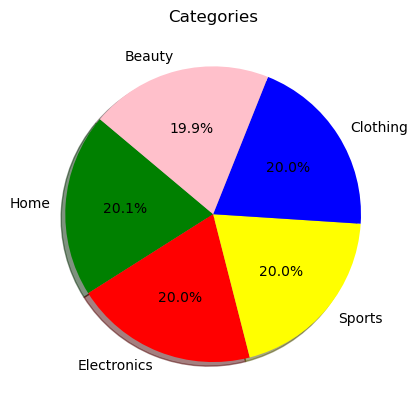

In [3]:
colors=["green","red","yellow","blue","pink"]

category_counts=df["category"].value_counts()
plt.pie(category_counts,labels=category_counts.index,colors=colors,autopct="%1.1f%%",shadow=True,startangle=140)
plt.title("Categories")
### INSIGHT
The database is almost evenly distributed across the five product categories.
Each category represent approximately 20% of the total products.
        

Text(0.5, 1.0, 'Payment Methods share')

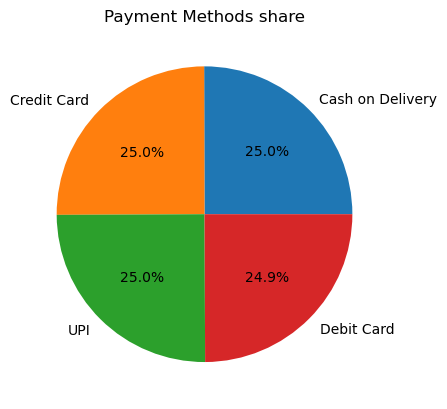

In [4]:
payment_method=df["payment_method"].value_counts()
plt.pie(payment_method,labels=payment_method.index,autopct="%1.1f%%")
plt.title("Payment Methods share")
### INSIGHT
Payment method usage is almost evenly distributed.


Text(0.5, 1.0, 'Return rate per category')

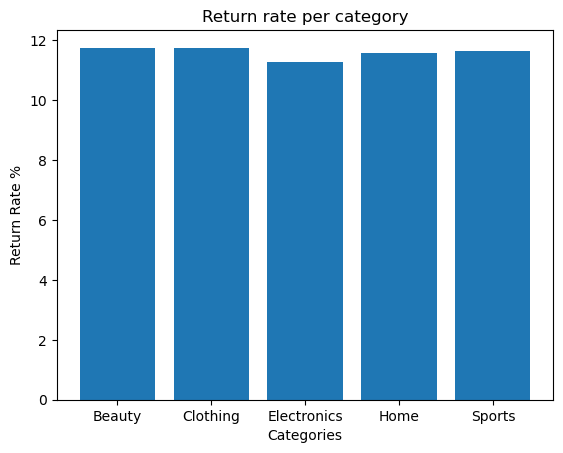

In [5]:
#return rate per category
return_category=df.groupby("category")["is_returned"].mean()*100
plt.bar(return_category.index,return_category.values)

plt.xlabel("Categories")
plt.ylabel("Return Rate %")
plt.title("Return rate per category")
###INSIGHT 
Return rates are relatively simiral across all product categories.
The difference between the categories is small ,suggesting that category alone does not show a strong difference in return rate in this dataset.

Text(0.5, 1.0, 'Shipping time-Return Rate')

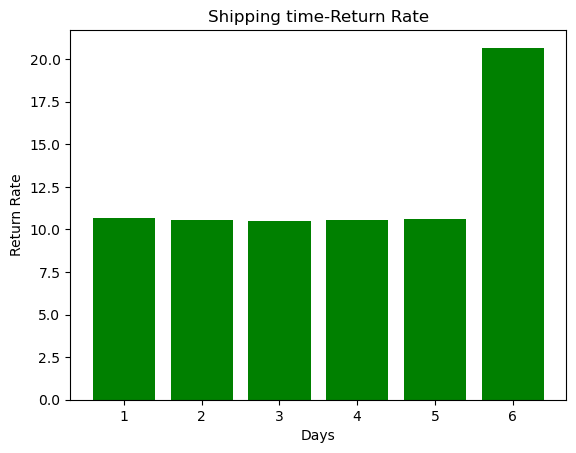

In [6]:
#does longer shipping time contrasted to more return
return_days=df.groupby("shipping_time_days")["is_returned"].mean()*100
plt.bar(return_days.index,return_days.values,color="green")
plt.xlabel("Days")
plt.ylabel("Return Rate")
plt.title("Shipping time-Return Rate")
### INSIGHT
Return rates remain relatively stable for products delivered within 1-5 days.
A noticeable increase in return rate is observed for product with 6-day shipping.

Text(0.5, 1.0, 'Rating effect on return rate')

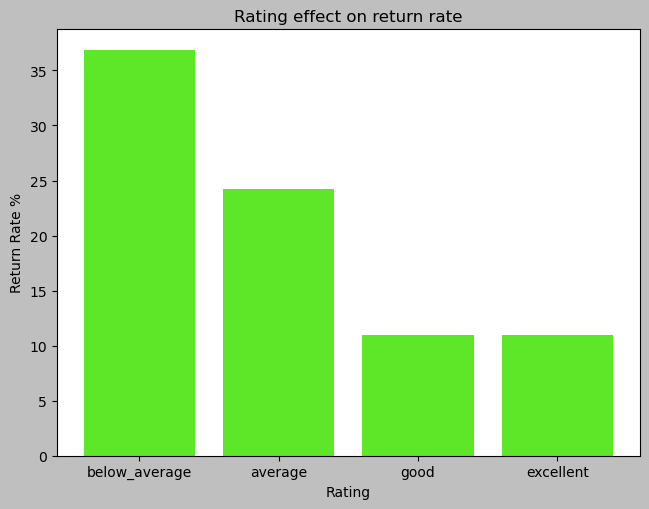

In [54]:
#how shipping effect return rate
bins=[0,1,2,3,4,5]
labels=["poor","below_average","average","good","excellent"]
df["rating_group"]=pd.cut(
    df["rating"],
    bins=bins,
    labels=labels)
rating_returned=df.groupby("rating_group",observed=True)["is_returned"].mean()*100
plt.bar(rating_returned.index,rating_returned.values,color="#5EE629")

plt.tight_layout()
plt.xlabel("Rating")
plt.ylabel("Return Rate %")
plt.title("Rating effect on return rate")
###INSIGHT
Products with below-average ratings have a noticeable higher return rate than products with higher rating.
Return rates decrease substantially as the rating improves.